<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_26_Feature_Importance_and_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import shap

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
pred = RF.predict(X_test)
accuracy= accuracy_score(y_test, pred)
print("Accuracy:",accuracy)

Accuracy: 0.9649122807017544


In [ ]:
importance  = pd.DataFrame({
    'feature': X_train.columns,
    'importance': RF.feature_importances_
})

In [ ]:
importance = importance.sort_values(by='importance', ascending=False)

In [ ]:
importance.head()

,feature,importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001


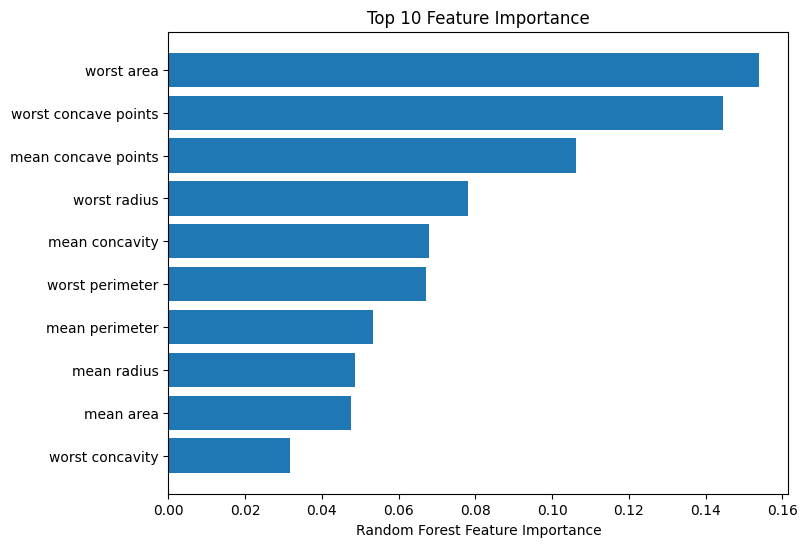

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(importance['feature'][:10], importance['importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Random Forest Feature Importance')
plt.title("Top 10 Feature Importance")
plt.show()

In [ ]:
explainer = shap.TreeExplainer(RF)
shap_values = explainer.shap_values(X_test)

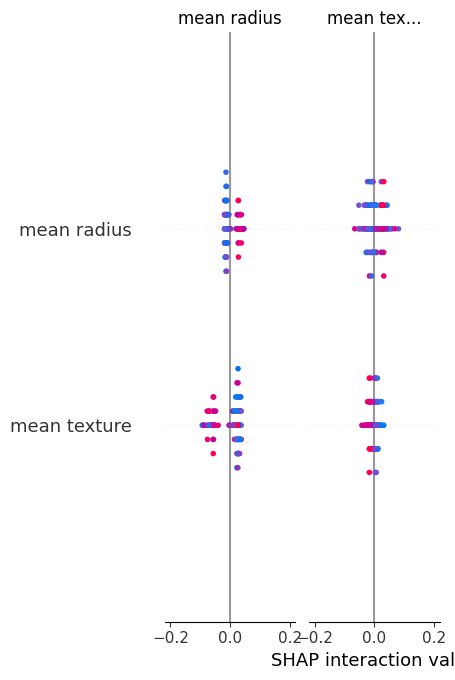

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type='bar')